In [21]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

In [22]:
# ── Load data ──────────────────────────────────────────────────────────────────
cols = ['mpg','cylinders','displacement','horsepower','weight',
        'acceleration','model_year','origin','car_name']
df = pd.read_csv('auto-mpg.data', sep=r'\s+', names=cols, na_values='?')
df = df.dropna()
 
X = df[['cylinders','displacement','horsepower','weight','acceleration','model_year','origin']]
y = df['mpg']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
 
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

In [23]:
# ── Train & evaluate ───────────────────────────────────────────────────────────
models = {
    'OLS':   LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0),
    'SVR':   SVR(kernel='rbf', C=100, epsilon=0.1),
}
 
results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)
    mse  = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, pred)
    results[name] = {'MSE': round(mse, 4), 'RMSE': round(rmse, 4), 'R2': round(r2, 4)}
    print(f"{name:6s} → MSE={mse:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}")

OLS    → MSE=10.7109  RMSE=3.2727  R²=0.7902
Ridge  → MSE=10.7674  RMSE=3.2814  R²=0.7890
Lasso  → MSE=10.0529  RMSE=3.1706  R²=0.8030
SVR    → MSE=5.7851  RMSE=2.4052  R²=0.8867


In [14]:
# Chọn feature & target
X = df[['weight']]
y = df['mpg']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ValueError: could not convert string to float: 'acceleration,'

In [19]:
# OLS
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)

# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

# Lasso
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

# SVR
svr = SVR(kernel='rbf', C=100, gamma=0.1)
svr.fit(X_train_scaled, y_train)

,kernel,'rbf'
,degree,3
,gamma,0.1
,coef0,0.0
,tol,0.001
,C,100
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [ ]:
y_pred_ols = ols.predict(X_test_scaled)
y_pred_ridge = ridge.predict(X_test_scaled)
y_pred_lasso = lasso.predict(X_test_scaled)
y_pred_svr = svr.predict(X_test_scaled)

In [ ]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"--- {name} ---")
    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2:   {r2:.4f}")
    print()

    return [name, mae, mse, rmse, r2]

In [20]:
results = []

results.append(evaluate_model("OLS", y_test, y_pred_ols))
results.append(evaluate_model("Ridge", y_test, y_pred_ridge))
results.append(evaluate_model("Lasso", y_test, y_pred_lasso))
results.append(evaluate_model("SVR", y_test, y_pred_svr))

NameError: name 'evaluate_model' is not defined

In [ ]:
plt.scatter(X_test_scaled, y_test, alpha=0.5)

sorted_idx = X_test_scaled[:,0].argsort()
plt.plot(X_test_scaled[sorted_idx], y_pred_ols[sorted_idx], linewidth=2)

plt.title("OLS Regression")
plt.xlabel("Weight (scaled)")
plt.ylabel("MPG")

plt.show()

C:\Users\khang\AppData\Local\Temp\ipykernel_15648\3221349041.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("auto-mpg.data",


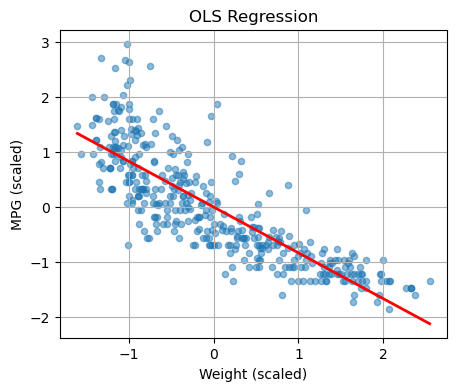

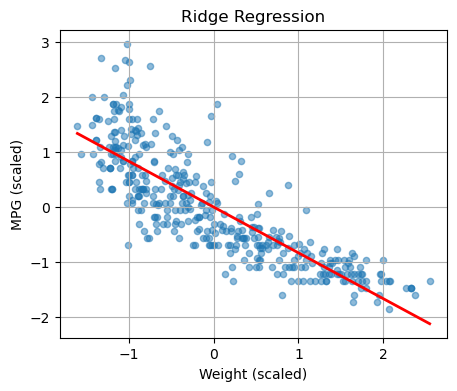

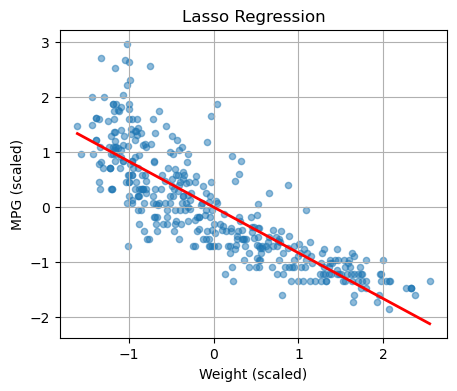

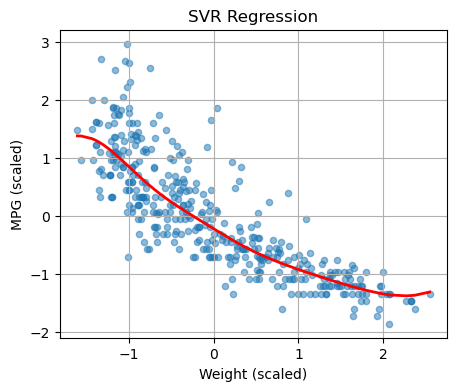

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# ======================
# 1. LOAD DATA
# ======================
df = pd.read_csv("auto-mpg.data",
                 delim_whitespace=True,
                 header=None,
                 names=["mpg","cylinders","displacement","horsepower",
                        "weight","acceleration","model_year","origin","car_name"])

# xử lý dữ liệu
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df = df.dropna()

# ======================
# 2. MODEL + PLOT
# ======================
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR

X = df[['weight']]
y = df['mpg']

# scale
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1)).ravel()

models = {
    "OLS": LinearRegression(),
    "Ridge": Ridge(alpha=0.01),
    "Lasso": Lasso(alpha=0.001),
    "SVR": SVR(kernel='rbf')
}

for name, model in models.items():
    model.fit(X_scaled, y_scaled)
    y_pred = model.predict(X_scaled)

    plt.figure(figsize=(5,4))

    # chỉ lấy feature weight để vẽ
    plt.scatter(X_scaled[:,0], y_scaled, alpha=0.5, s=20)

    # sort theo weight
    sorted_idx = X_scaled[:,0].argsort()

    plt.plot(X_scaled[:,0][sorted_idx], y_pred[sorted_idx],
         color='red', linewidth=2)

    plt.title(f"{name} Regression")
    plt.xlabel("Weight (scaled)")
    plt.ylabel("MPG (scaled)")
    plt.grid()

    plt.show()

In [18]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# danh sách alpha thử
param_grid = {'alpha': [0.01, 0.1, 1, 10, 50, 100]}

ridge = Ridge()

grid = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error')
grid.fit(X_scaled, y_scaled)

print("Best alpha (Ridge):", grid.best_params_)

Best alpha (Ridge): {'alpha': 0.01}


In [19]:
from sklearn.linear_model import Lasso

param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 5, 10]}

lasso = Lasso()

grid = GridSearchCV(lasso, param_grid, cv=5, scoring='neg_mean_squared_error')
grid.fit(X_scaled, y_scaled)

print("Best alpha (Lasso):", grid.best_params_)

Best alpha (Lasso): {'alpha': 0.001}
